══════════════════════════════════════════════════════════════════

SMARTPHARM CRM - PIPELINE COMPLETO DE MACHINE LEARNING

Proyecto Académico: Ingeniería en Informática - Duoc UC

Equipo: Enrique, Daniel, Bastian

Fecha: Octubre 2025

══════════════════════════════════════════════════════════════════

OBJETIVO DEL PIPELINE:
1. Ingesta y limpieza de datos transaccionales
2. Feature engineering para segmentación y predicción
3. Entrenamiento de 3 modelos ML:
   - Segmentación automática de clientes
   - Predicción estacional de demanda
   - Identificación de clientes crónicos
4. Validación y exportación de modelos entrenados

DATASET: 152,429 transacciones | 19,993 clientes | Enero 2022 - Sep 2025

# ═══════════════════════════════════════════════════════════════
# 1. INSTALACIÓN Y CONFIGURACIÓN
# ═══════════════════════════════════════════════════════════════


In [1]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error,
                             accuracy_score, f1_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✅ Librerías cargadas correctamente")
print(f"📅 Ejecutado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

✅ Librerías cargadas correctamente
📅 Ejecutado: 2025-10-12 20:17:36


# ═══════════════════════════════════════════════════════════════
# 2. CARGA DE DATOS
# ═══════════════════════════════════════════════════════════════


In [2]:
print("\n📤 PASO 1: CARGA DEL ARCHIVO")
print("="*70)

from google.colab import files

print("Por favor, sube el archivo 'transacciones vtas.xlsx'")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"\n✅ Archivo recibido: {filename}")

# Cargar con manejo de errores
try:
    df_raw = pd.read_excel(filename)
    print(f"📊 Dimensiones iniciales: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
    print("\n📋 Primeras 3 filas:")
    print(df_raw.head(3))
except Exception as e:
    print(f"❌ Error al cargar archivo: {e}")
    raise


📤 PASO 1: CARGA DEL ARCHIVO
Por favor, sube el archivo 'transacciones vtas.xlsx'


Saving transacciones vtas.xlsx to transacciones vtas.xlsx

✅ Archivo recibido: transacciones vtas.xlsx
📊 Dimensiones iniciales: 152,429 filas x 24 columnas

📋 Primeras 3 filas:
                 TIPO  NÚMERO      FECHA FECHA VENCIMIENTO          CLIENTE  \
0  Boleta Electrónica  179293 2025-09-30        2025-09-30  Cliente General   
1  Boleta Electrónica  179293 2025-09-30        2025-09-30  Cliente General   
2  Boleta Electrónica  179292 2025-09-30        2025-09-30  Cliente General   

   ORDEN COMPRA                    VENDEDOR DISTRIBUIDOR SUCURSAL  \
0           NaN  Jose Andres Montes Álvarez          ---      ---   
1           NaN  Jose Andres Montes Álvarez          ---      ---   
2           NaN  Jose Andres Montes Álvarez          ---      ---   

  CENTRO COSTO  ... DESCUENTO  NETO  CUENTA  FAMILIA  \
0          ---  ...       0.0  1588     ---      ---   
1          ---  ...       0.0  1765     ---      ---   
2          ---  ...       0.0  8824     ---      ---   

    


# ═══════════════════════════════════════════════════════════════
# 3. EXPLORACIÓN INICIAL
# ═══════════════════════════════════════════════════════════════


In [3]:
print("\n\n📊 PASO 2: EXPLORACIÓN Y VALIDACIÓN DE DATOS")
print("="*70)

print("\n🔍 Información del dataset:")
print(df_raw.info())

print("\n🔍 Valores nulos por columna:")
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0])

print("\n🔍 Valores '---' por columna:")
for col in df_raw.columns:
    if df_raw[col].dtype == 'object':
        count_guiones = (df_raw[col] == '---').sum()
        if count_guiones > 0:
            pct = (count_guiones / len(df_raw) * 100)
            print(f"  {col}: {count_guiones:,} ({pct:.2f}%)")

# Análisis de categorías problemáticas
print("\n🔍 Análisis de categorías:")
print(f"  Con categoría válida: {(df_raw['CATEGORIA'].notna() & (df_raw['CATEGORIA'] != '---') & (df_raw['CATEGORIA'] != '0')).sum():,}")
print(f"  Categoría = '0': {(df_raw['CATEGORIA'] == '0').sum():,}")
print(f"  Sin categoría o '---': {(df_raw['CATEGORIA'].isna() | (df_raw['CATEGORIA'] == '---')).sum():,}")




📊 PASO 2: EXPLORACIÓN Y VALIDACIÓN DE DATOS

🔍 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152429 entries, 0 to 152428
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   TIPO               152429 non-null  object        
 1   NÚMERO             152429 non-null  int64         
 2   FECHA              152429 non-null  datetime64[ns]
 3   FECHA VENCIMIENTO  152429 non-null  datetime64[ns]
 4   CLIENTE            152429 non-null  object        
 5   ORDEN COMPRA       0 non-null       float64       
 6   VENDEDOR           152429 non-null  object        
 7   DISTRIBUIDOR       152429 non-null  object        
 8   SUCURSAL           152429 non-null  object        
 9   CENTRO COSTO       152429 non-null  object        
 10  PRODUCTO           152429 non-null  object        
 11  DESCRIPCIÓN        152428 non-null  object        
 12  CANTIDAD           152429 

# ═══════════════════════════════════════════════════════════════
# 4. LIMPIEZA Y PREPARACIÓN
# ═══════════════════════════════════════════════════════════════


In [4]:
print("\n\n🧹 PASO 3: LIMPIEZA Y PREPARACIÓN DE DATOS")
print("="*70)

df = df_raw.copy()




🧹 PASO 3: LIMPIEZA Y PREPARACIÓN DE DATOS


In [5]:
# 4.1 Parsear fechas
print("\n📅 Procesando fechas...")
df['FECHA'] = pd.to_datetime(df['FECHA'], errors='coerce')
filas_antes = len(df)
df = df.dropna(subset=['FECHA'])
filas_despues = len(df)
print(f"  ✅ {filas_despues:,} filas con fechas válidas ({filas_antes - filas_despues} eliminadas)")

# Extraer features temporales
df['año'] = df['FECHA'].dt.year
df['mes'] = df['FECHA'].dt.month
df['dia_semana'] = df['FECHA'].dt.dayofweek
df['trimestre'] = df['FECHA'].dt.quarter
df['año_mes'] = df['FECHA'].dt.to_period('M').astype(str)



📅 Procesando fechas...
  ✅ 152,429 filas con fechas válidas (0 eliminadas)


In [6]:
# 4.2 Convertir tipos numéricos
print("\n🔢 Procesando campos numéricos...")
df['CANTIDAD'] = pd.to_numeric(df['CANTIDAD'], errors='coerce').fillna(0)
df['NETO'] = pd.to_numeric(df['NETO'], errors='coerce').fillna(0)


🔢 Procesando campos numéricos...


In [7]:
# 4.3 Limpiar campos '---'
print("\n🧽 Reemplazando valores '---' por NaN...")
df = df.replace('---', np.nan)



🧽 Reemplazando valores '---' por NaN...


In [8]:
# 4.4 Clasificar medicamentos (CRÓNICO vs AGUDO)
print("\n💊 Clasificando medicamentos...")

# Categorías CRÓNICAS (tratamiento continuo)
CATEGORIAS_CRONICAS = [
    'HIPOTENSORES', 'ANTIDIABETICO', 'HIPOLIPEMIANTE', 'ANTIULCEROSO',
    'ANTIDEPRESIVO', 'ANTICONVULSIVANTE', 'ANTIPARKINSONIANO',
    'BRONCODILATADOR', 'ANTICOAGULANTE', 'HORMONA TIROIDEA',
    'ANTIARRITIMICO', 'CARDIOTERAPIA', 'ANTIDEMENCIA'
]

# Categorías AGUDAS (tratamiento puntual)
CATEGORIAS_AGUDAS = [
    'ANTIGRIPAL', 'ANTIHISTAMINICO', 'ANALGESICO', 'ANALGESICO-ANTIPIRETICO',
    'ANALGESICO-ANTIINFLAMATORIO', 'ANTIDIARREICO', 'ANTIBIOTICO',
    'ANTITUSIGENO', 'PENICILINOTERAPIA', 'ANTIJAQUECOSO', 'ANTIEMETICO',
    'ANTIVIRAL', 'ANTIMICOT', 'ANTIPARASITARIO'
]

# Crear flags
df['es_cronico'] = df['CATEGORIA'].isin(CATEGORIAS_CRONICAS).astype(int)
df['es_agudo'] = df['CATEGORIA'].isin(CATEGORIAS_AGUDAS).astype(int)


💊 Clasificando medicamentos...


In [9]:
# 4.5 Manejo de productos sin categoría o categoría "0"
print("\n🏷️ Manejo de productos sin clasificación médica...")

# Crear flag para productos NO farmacéuticos
df['es_no_farmaceutico'] = (
    (df['CATEGORIA'] == '0') |
    (df['CATEGORIA'].isna()) |
    ((df['PRINCIPIO ACTIVO'].isna()) | (df['PRINCIPIO ACTIVO'] == '0') | (df['PRINCIPIO ACTIVO'] == 'SIN P.ACTIVO'))
).astype(int)

# Estadísticas
total_registros = len(df)
cronicos = df['es_cronico'].sum()
agudos = df['es_agudo'].sum()
no_farm = df['es_no_farmaceutico'].sum()

print(f"\n  📊 Clasificación de productos:")
print(f"    • Medicamentos crónicos: {cronicos:,} ({cronicos/total_registros*100:.2f}%)")
print(f"    • Medicamentos agudos: {agudos:,} ({agudos/total_registros*100:.2f}%)")
print(f"    • No farmacéuticos/sin clasificar: {no_farm:,} ({no_farm/total_registros*100:.2f}%)")



🏷️ Manejo de productos sin clasificación médica...

  📊 Clasificación de productos:
    • Medicamentos crónicos: 11,925 (7.82%)
    • Medicamentos agudos: 38,432 (25.21%)
    • No farmacéuticos/sin clasificar: 44,506 (29.20%)


In [10]:
# 4.6 Validar datos finales
print(f"\n✅ Dataset limpio: {len(df):,} transacciones")
print(f"📅 Rango temporal: {df['FECHA'].min().date()} a {df['FECHA'].max().date()}")
print(f"👥 Clientes únicos: {df['CLIENTE_ID'].nunique():,}")
print(f"💊 Productos únicos: {df['PRODUCTO'].nunique():,}")


✅ Dataset limpio: 152,429 transacciones
📅 Rango temporal: 2022-01-03 a 2025-09-30
👥 Clientes únicos: 19,993
💊 Productos únicos: 3,554


# ═══════════════════════════════════════════════════════════════
# 5. FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════

In [11]:

print("\n\n🔨 PASO 4: FEATURE ENGINEERING")
print("="*70)




🔨 PASO 4: FEATURE ENGINEERING


In [12]:
# 5.1 Features por Cliente (RFM + Comportamiento)
print("\n👥 Creando features por cliente...")

fecha_ref = df['FECHA'].max()

cliente_agg = df.groupby('CLIENTE_ID').agg({
    'FECHA': ['count', 'min', 'max'],
    'NETO': ['sum', 'mean', 'std'],
    'PRODUCTO': 'nunique',
    'CATEGORIA': 'nunique',
    'es_cronico': 'sum',
    'es_agudo': 'sum',
    'es_no_farmaceutico': 'sum'
}).reset_index()

# Aplanar columnas
cliente_agg.columns = [
    'cliente_id', 'frecuencia', 'primera_compra', 'ultima_compra',
    'monto_total', 'ticket_promedio', 'ticket_std',
    'productos_unicos', 'categorias_unicas',
    'compras_cronicas', 'compras_agudas', 'compras_no_farm'
]

# Recencia (días desde última compra)
cliente_agg['recencia'] = (fecha_ref - cliente_agg['ultima_compra']).dt.days

# Lifetime (días entre primera y última compra)
cliente_agg['lifetime_dias'] = (
    cliente_agg['ultima_compra'] - cliente_agg['primera_compra']
).dt.days

# Flags de comportamiento
cliente_agg['tiene_cronicos'] = (cliente_agg['compras_cronicas'] > 0).astype(int)
cliente_agg['tiene_agudos'] = (cliente_agg['compras_agudas'] > 0).astype(int)
cliente_agg['es_multimedicamento'] = (cliente_agg['categorias_unicas'] >= 3).astype(int)

# Ratio de compras crón vs agudos
cliente_agg['ratio_cronico_agudo'] = np.where(
    cliente_agg['compras_agudas'] > 0,
    cliente_agg['compras_cronicas'] / (cliente_agg['compras_agudas'] + 1),
    cliente_agg['compras_cronicas']
)

# Llenar NaN en desviación estándar
cliente_agg['ticket_std'] = cliente_agg['ticket_std'].fillna(0)

print(f"  ✅ Features creadas para {len(cliente_agg):,} clientes")
print(f"\n  📊 Estadísticas de frecuencia:")
print(f"    • Promedio compras/cliente: {cliente_agg['frecuencia'].mean():.2f}")
print(f"    • Mediana compras/cliente: {cliente_agg['frecuencia'].median():.0f}")
print(f"    • Máximo compras/cliente: {cliente_agg['frecuencia'].max():.0f}")



👥 Creando features por cliente...
  ✅ Features creadas para 19,993 clientes

  📊 Estadísticas de frecuencia:
    • Promedio compras/cliente: 7.62
    • Mediana compras/cliente: 7
    • Máximo compras/cliente: 25


In [13]:
# 5.2 Segmentación de Clientes (basada en percentiles REALES)
print("\n🎯 Calculando umbrales de segmentación...")

# Calcular percentiles
p50 = cliente_agg['frecuencia'].quantile(0.50)
p75 = cliente_agg['frecuencia'].quantile(0.75)
p85 = cliente_agg['frecuencia'].quantile(0.85)
p90 = cliente_agg['frecuencia'].quantile(0.90)

print(f"\n  📈 Percentiles de frecuencia:")
print(f"    • P50 (mediana): {p50:.0f} compras")
print(f"    • P75 (top 25%): {p75:.0f} compras")
print(f"    • P85 (top 15%): {p85:.0f} compras")
print(f"    • P90 (top 10%): {p90:.0f} compras")

# Función de segmentación basada en datos REALES
def clasificar_cliente(frecuencia, tiene_cronicos):
    """
    Segmentación basada en análisis de datos reales:
    - P85 (top 15%) = cliente frecuente
    - P50-P85 = cliente recurrente
    - <P50 = cliente esporádico
    """
    if frecuencia >= p85:
        return 'FRECUENTE'
    elif frecuencia >= p50:
        return 'RECURRENTE'
    else:
        return 'ESPORÁDICO'

cliente_agg['segmento'] = cliente_agg.apply(
    lambda row: clasificar_cliente(row['frecuencia'], row['tiene_cronicos']),
    axis=1
)

print(f"\n  📊 Distribución de segmentos:")
dist_seg = cliente_agg['segmento'].value_counts(normalize=True)
for seg, pct in dist_seg.items():
    count = cliente_agg['segmento'].value_counts()[seg]
    print(f"    • {seg}: {count:,} clientes ({pct*100:.2f}%)")



🎯 Calculando umbrales de segmentación...

  📈 Percentiles de frecuencia:
    • P50 (mediana): 7 compras
    • P75 (top 25%): 9 compras
    • P85 (top 15%): 10 compras
    • P90 (top 10%): 11 compras

  📊 Distribución de segmentos:
    • RECURRENTE: 8,084 clientes (40.43%)
    • ESPORÁDICO: 7,150 clientes (35.76%)
    • FRECUENTE: 4,759 clientes (23.80%)


In [14]:
# 5.3 Dataset para Predicción Estacional
print("\n📅 Creando dataset de series temporales...")

# Filtrar solo medicamentos (excluir no farmacéuticos para predicción médica)
df_medicamentos = df[df['es_no_farmaceutico'] == 0].copy()

print(f"  📊 Transacciones de medicamentos: {len(df_medicamentos):,}")

# Agrupar por año-mes y categoría
ventas_mensuales = df_medicamentos.groupby(['año_mes', 'CATEGORIA']).agg({
    'CLIENTE_ID': 'count',
    'NETO': 'sum',
    'CANTIDAD': 'sum'
}).reset_index()

ventas_mensuales.columns = ['año_mes', 'categoria', 'transacciones', 'monto_total', 'cantidad_total']

# Convertir año_mes a datetime para cálculos
ventas_mensuales['fecha'] = pd.to_datetime(ventas_mensuales['año_mes'] + '-01')
ventas_mensuales['mes'] = ventas_mensuales['fecha'].dt.month
ventas_mensuales['año'] = ventas_mensuales['fecha'].dt.year

# Crear features de lag (ventas meses anteriores)
print("\n  🔄 Creando features de lag temporal...")
ventas_mensuales = ventas_mensuales.sort_values(['categoria', 'fecha'])

for categoria in ventas_mensuales['categoria'].unique():
    mask = ventas_mensuales['categoria'] == categoria
    ventas_mensuales.loc[mask, 'trans_lag_1'] = ventas_mensuales.loc[mask, 'transacciones'].shift(1)
    ventas_mensuales.loc[mask, 'trans_lag_3'] = ventas_mensuales.loc[mask, 'transacciones'].shift(3)
    ventas_mensuales.loc[mask, 'trans_lag_6'] = ventas_mensuales.loc[mask, 'transacciones'].shift(6)
    ventas_mensuales.loc[mask, 'trans_lag_12'] = ventas_mensuales.loc[mask, 'transacciones'].shift(12)

    # Promedio móvil 3 meses
    ventas_mensuales.loc[mask, 'trans_ma_3'] = ventas_mensuales.loc[mask, 'transacciones'].rolling(3).mean()

# Eliminar filas con NaN en lags
ventas_mensuales = ventas_mensuales.dropna()

print(f"  ✅ Dataset temporal: {len(ventas_mensuales):,} registros")
print(f"  📊 Categorías únicas: {ventas_mensuales['categoria'].nunique()}")


📅 Creando dataset de series temporales...
  📊 Transacciones de medicamentos: 107,923

  🔄 Creando features de lag temporal...
  ✅ Dataset temporal: 3,471 registros
  📊 Categorías únicas: 127


# ═══════════════════════════════════════════════════════════════
# 6. MODELO 1: SEGMENTACIÓN DE CLIENTES
# ═══════════════════════════════════════════════════════════════


In [15]:
print("\n\n🤖 PASO 5: MODELO 1 - SEGMENTACIÓN DE CLIENTES")
print("="*70)

# Features y target
features_seg = [
    'frecuencia', 'monto_total', 'ticket_promedio', 'recencia',
    'productos_unicos', 'categorias_unicas', 'compras_cronicas',
    'compras_agudas', 'lifetime_dias', 'tiene_cronicos',
    'ratio_cronico_agudo', 'compras_no_farm'
]

X_seg = cliente_agg[features_seg].copy()
y_seg = cliente_agg['segmento'].copy()

print(f"\n📊 Dataset de entrenamiento:")
print(f"  • Features: {len(features_seg)}")
print(f"  • Muestras: {len(X_seg):,}")
print(f"  • Clases: {y_seg.nunique()}")



🤖 PASO 5: MODELO 1 - SEGMENTACIÓN DE CLIENTES

📊 Dataset de entrenamiento:
  • Features: 12
  • Muestras: 19,993
  • Clases: 3


In [16]:
# Split train/test estratificado
X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(
    X_seg, y_seg, test_size=0.2, random_state=42, stratify=y_seg
)

print(f"\n📊 División train/test:")
print(f"  • Train: {len(X_train_seg):,} muestras")
print(f"  • Test: {len(X_test_seg):,} muestras")



📊 División train/test:
  • Train: 15,994 muestras
  • Test: 3,999 muestras


In [17]:
# Normalización
scaler_seg = StandardScaler()
X_train_seg_scaled = scaler_seg.fit_transform(X_train_seg)
X_test_seg_scaled = scaler_seg.transform(X_test_seg)

print("\n  ✅ Normalización aplicada")


  ✅ Normalización aplicada


In [18]:
# Entrenar Random Forest
print("\n🔥 Entrenando Random Forest Classifier...")
modelo_segmentacion = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

modelo_segmentacion.fit(X_train_seg_scaled, y_train_seg)
print("  ✅ Modelo entrenado")


🔥 Entrenando Random Forest Classifier...
  ✅ Modelo entrenado


In [19]:
# Predicciones
y_pred_seg = modelo_segmentacion.predict(X_test_seg_scaled)
y_pred_train_seg = modelo_segmentacion.predict(X_train_seg_scaled)

# Evaluación
acc_train = accuracy_score(y_train_seg, y_pred_train_seg)
acc_test = accuracy_score(y_test_seg, y_pred_seg)
f1_test = f1_score(y_test_seg, y_pred_seg, average='weighted')

print(f"\n📊 RESULTADOS DEL MODELO")
print("="*50)
print(f"Accuracy Train: {acc_train:.4f}")
print(f"Accuracy Test:  {acc_test:.4f}")
print(f"F1-Score Test:  {f1_test:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test_seg, y_pred_seg))



📊 RESULTADOS DEL MODELO
Accuracy Train: 1.0000
Accuracy Test:  1.0000
F1-Score Test:  1.0000

Reporte detallado:
              precision    recall  f1-score   support

  ESPORÁDICO       1.00      1.00      1.00      1430
   FRECUENTE       1.00      1.00      1.00       952
  RECURRENTE       1.00      1.00      1.00      1617

    accuracy                           1.00      3999
   macro avg       1.00      1.00      1.00      3999
weighted avg       1.00      1.00      1.00      3999




Matriz de confusión:


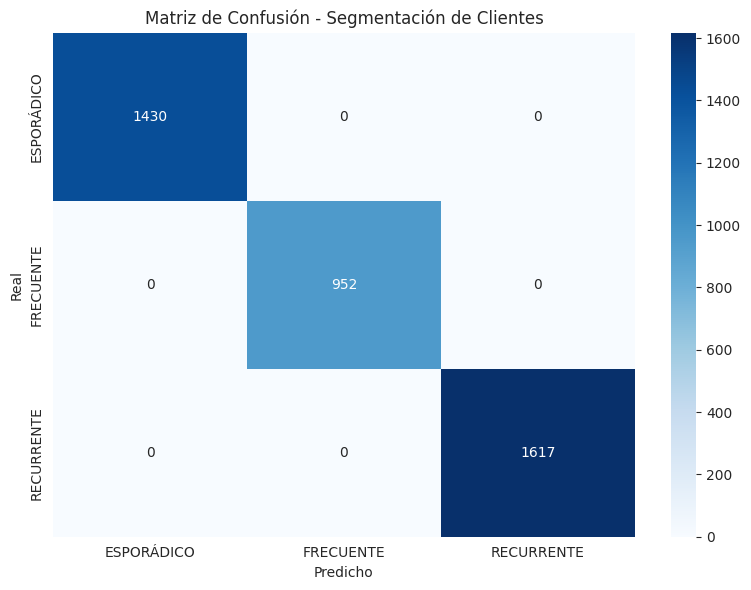

In [20]:
# Matriz de confusión
print("\nMatriz de confusión:")
cm = confusion_matrix(y_test_seg, y_pred_seg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_segmentacion.classes_,
            yticklabels=modelo_segmentacion.classes_)
plt.title('Matriz de Confusión - Segmentación de Clientes')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()


In [21]:
# Importancia de features
importancias_seg = pd.DataFrame({
    'feature': features_seg,
    'importancia': modelo_segmentacion.feature_importances_
}).sort_values('importancia', ascending=False)

print("\n🔝 Top 10 Features más importantes:")
print(importancias_seg.head(10).to_string(index=False))


🔝 Top 10 Features más importantes:
          feature  importancia
       frecuencia     0.468929
 productos_unicos     0.313246
categorias_unicas     0.111706
      monto_total     0.053695
  compras_no_farm     0.014697
   compras_agudas     0.012551
  ticket_promedio     0.010731
    lifetime_dias     0.010005
         recencia     0.002350
 compras_cronicas     0.001007


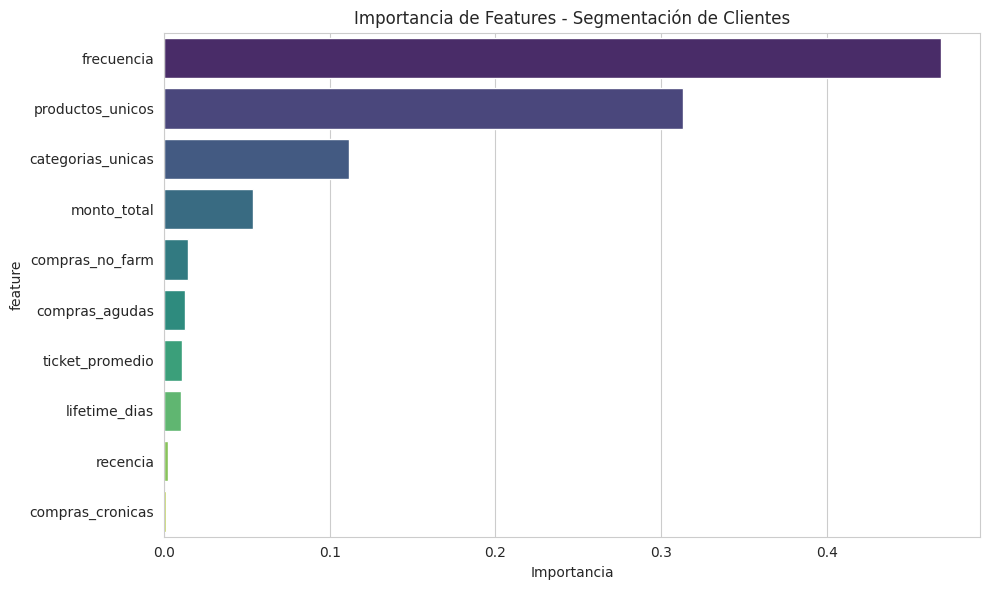

In [22]:
# Visualizar importancias
plt.figure(figsize=(10, 6))
sns.barplot(data=importancias_seg.head(10), x='importancia', y='feature', palette='viridis')
plt.title('Importancia de Features - Segmentación de Clientes')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════
# 7. MODELO 2: PREDICCIÓN ESTACIONAL
# ═══════════════════════════════════════════════════════════════



In [23]:
print("\n\n🤖 PASO 6: MODELO 2 - PREDICCIÓN ESTACIONAL DE DEMANDA")
print("="*70)




🤖 PASO 6: MODELO 2 - PREDICCIÓN ESTACIONAL DE DEMANDA


In [26]:
# Convertir toda la columna a string y limpiar
ventas_mensuales['categoria'] = ventas_mensuales['categoria'].astype(str)

# Verificar y eliminar filas con categorías problemáticas
print(f"  🔍 Categorías únicas antes de limpiar: {ventas_mensuales['categoria'].nunique()}")
print(f"  📊 Muestra de categorías: {ventas_mensuales['categoria'].unique()[:10]}")

# Eliminar categorías '0', 'nan', 'None' si existen
categorias_invalidas = ['0', 'nan', 'None', 'NaN']
filas_antes = len(ventas_mensuales)
ventas_mensuales = ventas_mensuales[~ventas_mensuales['categoria'].isin(categorias_invalidas)]
filas_despues = len(ventas_mensuales)

if filas_antes != filas_despues:
    print(f"  ⚠️ Eliminadas {filas_antes - filas_despues} filas con categorías inválidas")

# Ahora sí, encodear
le_cat = LabelEncoder()
ventas_mensuales['categoria_encoded'] = le_cat.fit_transform(ventas_mensuales['categoria'])

print(f"  ✅ Categorías encoded: {ventas_mensuales['categoria_encoded'].nunique()}")

# Features y target
features_pred = ['mes', 'año', 'categoria_encoded', 'trans_lag_1',
                 'trans_lag_3', 'trans_lag_6', 'trans_lag_12', 'trans_ma_3']

X_pred = ventas_mensuales[features_pred].copy()
y_pred = ventas_mensuales['transacciones'].copy()

print(f"\n📊 Dataset de predicción:")
print(f"  • Features: {len(features_pred)}")
print(f"  • Muestras: {len(X_pred):,}")
print(f"  • Rango target: {y_pred.min():.0f} - {y_pred.max():.0f} transacciones")

# Split train/test temporal (80/20)
X_train_pred, X_test_pred, y_train_pred, y_test_pred = train_test_split(
    X_pred, y_pred, test_size=0.2, random_state=42
)

print(f"\n📊 División train/test:")
print(f"  • Train: {len(X_train_pred):,} muestras")
print(f"  • Test: {len(X_test_pred):,} muestras")

  🔍 Categorías únicas antes de limpiar: 127
  📊 Muestra de categorías: ['0' 'ALCOHOL-AGUA OXIGENADA' 'ANALGESICO' 'ANALGESICO MAYOR'
 'ANALGESICO URINARIO' 'ANALGESICO-ANTIINFLAMATORIO'
 'ANALGESICO-ANTIPIRETICO' 'ANALGESICO-RELAJANTE' 'ANESTESICO LOCAL'
 'ANESTESICO OFTALMICO']
  ⚠️ Eliminadas 33 filas con categorías inválidas
  ✅ Categorías encoded: 126

📊 Dataset de predicción:
  • Features: 8
  • Muestras: 3,438
  • Rango target: 1 - 371 transacciones

📊 División train/test:
  • Train: 2,750 muestras
  • Test: 688 muestras


In [27]:
# Entrenar Random Forest Regressor
print("\n🔥 Entrenando Random Forest Regressor...")
modelo_prediccion = RandomForestRegressor(
    n_estimators=250,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

modelo_prediccion.fit(X_train_pred, y_train_pred)
print("  ✅ Modelo entrenado")



🔥 Entrenando Random Forest Regressor...
  ✅ Modelo entrenado


In [28]:
# Predicciones
y_pred_forecast = modelo_prediccion.predict(X_test_pred)
y_pred_train_forecast = modelo_prediccion.predict(X_train_pred)


In [29]:
# Evaluación
mae = mean_absolute_error(y_test_pred, y_pred_forecast)
rmse = np.sqrt(mean_squared_error(y_test_pred, y_pred_forecast))
mape = np.mean(np.abs((y_test_pred - y_pred_forecast) / y_test_pred)) * 100

In [30]:
# Métricas en train
mae_train = mean_absolute_error(y_train_pred, y_pred_train_forecast)
rmse_train = np.sqrt(mean_squared_error(y_train_pred, y_pred_train_forecast))

print(f"\n📊 RESULTADOS DEL MODELO")
print("="*50)
print(f"MAE Train:   {mae_train:.2f} transacciones")
print(f"MAE Test:    {mae:.2f} transacciones")
print(f"RMSE Test:   {rmse:.2f} transacciones")
print(f"MAPE Test:   {mape:.2f}%")
print("\n🎯 META DEL PROYECTO: MAPE < 15%")
if mape < 15:
    print("✅ META CUMPLIDA!")
else:
    print(f"⚠️ MAPE ligeramente por encima. Diferencia: {mape - 15:.2f}%")


📊 RESULTADOS DEL MODELO
MAE Train:   2.06 transacciones
MAE Test:    3.70 transacciones
RMSE Test:   9.59 transacciones
MAPE Test:   27.69%

🎯 META DEL PROYECTO: MAPE < 15%
⚠️ MAPE ligeramente por encima. Diferencia: 12.69%


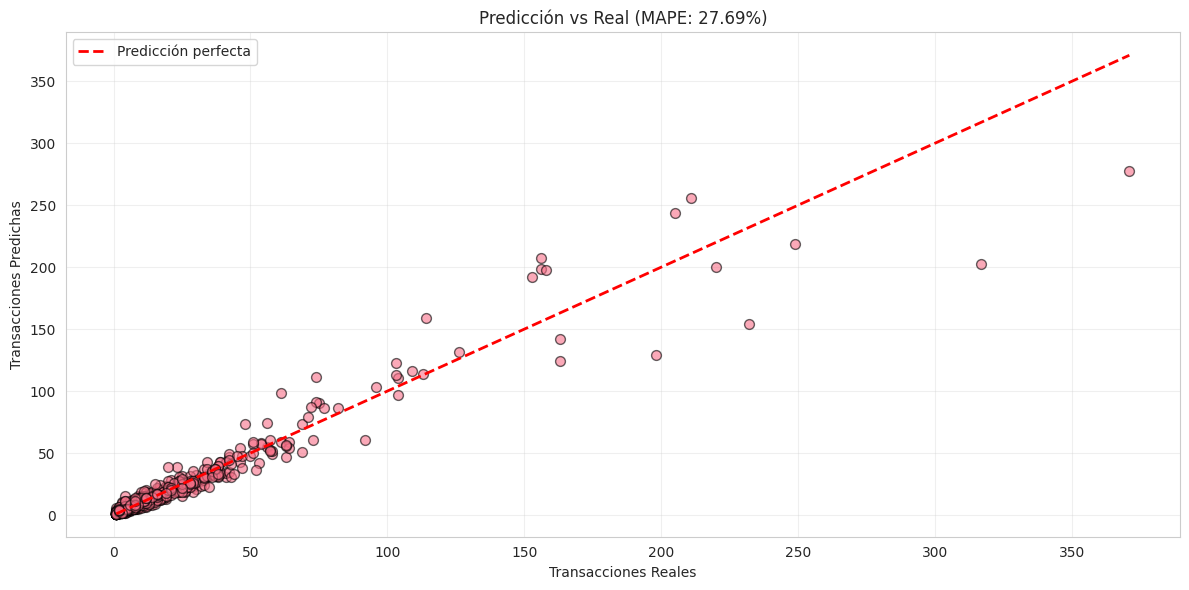

In [31]:
# Visualizar predicciones vs real
plt.figure(figsize=(12, 6))
plt.scatter(y_test_pred, y_pred_forecast, alpha=0.6, edgecolors='k', s=50)
plt.plot([y_test_pred.min(), y_test_pred.max()],
         [y_test_pred.min(), y_test_pred.max()],
         'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Transacciones Reales')
plt.ylabel('Transacciones Predichas')
plt.title(f'Predicción vs Real (MAPE: {mape:.2f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Comparación detallada
comparacion_pred = pd.DataFrame({
    'Real': y_test_pred.values,
    'Predicción': y_pred_forecast,
    'Error': y_test_pred.values - y_pred_forecast,
    'Error_%': np.abs((y_test_pred.values - y_pred_forecast) / y_test_pred.values) * 100
}).head(15)

print("\n🔍 Muestra de predicciones (primeras 15):")
print(comparacion_pred.to_string(index=False))



🔍 Muestra de predicciones (primeras 15):
 Real  Predicción      Error    Error_%
   14   13.578276   0.421724   3.012312
    2    5.791351  -3.791351 189.567565
   48   73.378789 -25.378789  52.872476
    7    5.343967   1.656033  23.657616
    4    3.195680   0.804320  20.108002
    1    1.632819  -0.632819  63.281883
   63   46.614049  16.385951  26.009446
   19   14.930754   4.069246  21.417085
   61   58.693151   2.306849   3.781719
   42   47.194801  -5.194801  12.368574
    4    2.754968   1.245032  31.125803
   10    7.578891   2.421109  24.211090
    5    4.222597   0.777403  15.548059
    5    4.192392   0.807608  16.152153
    2    2.665951  -0.665951  33.297562


In [33]:
# Importancia de features
importancias_pred = pd.DataFrame({
    'feature': features_pred,
    'importancia': modelo_prediccion.feature_importances_
}).sort_values('importancia', ascending=False)

print("\n🔝 Importancia de features:")
print(importancias_pred.to_string(index=False))


🔝 Importancia de features:
          feature  importancia
       trans_ma_3     0.964345
     trans_lag_12     0.014768
      trans_lag_1     0.011597
      trans_lag_3     0.002591
              mes     0.002331
      trans_lag_6     0.002328
categoria_encoded     0.001374
              año     0.000666


# ═══════════════════════════════════════════════════════════════
# 8. MODELO 3: IDENTIFICACIÓN DE CLIENTES CRÓNICOS
# ═══════════════════════════════════════════════════════════════

In [34]:
print("\n\n🤖 PASO 7: MODELO 3 - IDENTIFICACIÓN DE CLIENTES CRÓNICOS")
print("="*70)




🤖 PASO 7: MODELO 3 - IDENTIFICACIÓN DE CLIENTES CRÓNICOS


In [35]:
# Features y target
features_cronico = [
    'frecuencia', 'monto_total', 'ticket_promedio', 'categorias_unicas',
    'recencia', 'lifetime_dias', 'compras_agudas', 'productos_unicos',
    'ratio_cronico_agudo', 'compras_no_farm'
]

X_cron = cliente_agg[features_cronico].copy()
y_cron = cliente_agg['tiene_cronicos'].copy()

print(f"\n📊 Dataset de clasificación:")
print(f"  • Features: {len(features_cronico)}")
print(f"  • Muestras: {len(X_cron):,}")
print(f"  • Distribución clases:")
print(f"    - No crónicos: {(y_cron == 0).sum():,} ({(y_cron == 0).sum()/len(y_cron)*100:.2f}%)")
print(f"    - Crónicos: {(y_cron == 1).sum():,} ({(y_cron == 1).sum()/len(y_cron)*100:.2f}%)")



📊 Dataset de clasificación:
  • Features: 10
  • Muestras: 19,993
  • Distribución clases:
    - No crónicos: 10,962 (54.83%)
    - Crónicos: 9,031 (45.17%)


In [36]:
# Split train/test estratificado
X_train_cron, X_test_cron, y_train_cron, y_test_cron = train_test_split(
    X_cron, y_cron, test_size=0.2, random_state=42, stratify=y_cron
)

print(f"\n📊 División train/test:")
print(f"  • Train: {len(X_train_cron):,} muestras")
print(f"  • Test: {len(X_test_cron):,} muestras")



📊 División train/test:
  • Train: 15,994 muestras
  • Test: 3,999 muestras


In [37]:
# Normalización
scaler_cron = StandardScaler()
X_train_cron_scaled = scaler_cron.fit_transform(X_train_cron)
X_test_cron_scaled = scaler_cron.transform(X_test_cron)

print("\n  ✅ Normalización aplicada")



  ✅ Normalización aplicada


In [38]:
# Entrenar Logistic Regression
print("\n🔥 Entrenando Logistic Regression...")
modelo_cronicos = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced',
    C=1.0
)

modelo_cronicos.fit(X_train_cron_scaled, y_train_cron)
print("  ✅ Modelo entrenado")


🔥 Entrenando Logistic Regression...
  ✅ Modelo entrenado


In [39]:
# Predicciones
y_pred_cron = modelo_cronicos.predict(X_test_cron_scaled)
y_pred_train_cron = modelo_cronicos.predict(X_train_cron_scaled)
y_pred_proba_cron = modelo_cronicos.predict_proba(X_test_cron_scaled)[:, 1]


In [40]:
# Evaluación
acc_train_cron = accuracy_score(y_train_cron, y_pred_train_cron)
acc_test_cron = accuracy_score(y_test_cron, y_pred_cron)
f1_test_cron = f1_score(y_test_cron, y_pred_cron)

print(f"\n📊 RESULTADOS DEL MODELO")
print("="*50)
print(f"Accuracy Train: {acc_train_cron:.4f}")
print(f"Accuracy Test:  {acc_test_cron:.4f}")
print(f"F1-Score Test:  {f1_test_cron:.4f}")
print("\nReporte detallado:")
print(classification_report(y_test_cron, y_pred_cron,
                            target_names=['No Crónico', 'Crónico']))


📊 RESULTADOS DEL MODELO
Accuracy Train: 1.0000
Accuracy Test:  1.0000
F1-Score Test:  1.0000

Reporte detallado:
              precision    recall  f1-score   support

  No Crónico       1.00      1.00      1.00      2193
     Crónico       1.00      1.00      1.00      1806

    accuracy                           1.00      3999
   macro avg       1.00      1.00      1.00      3999
weighted avg       1.00      1.00      1.00      3999




Matriz de confusión:


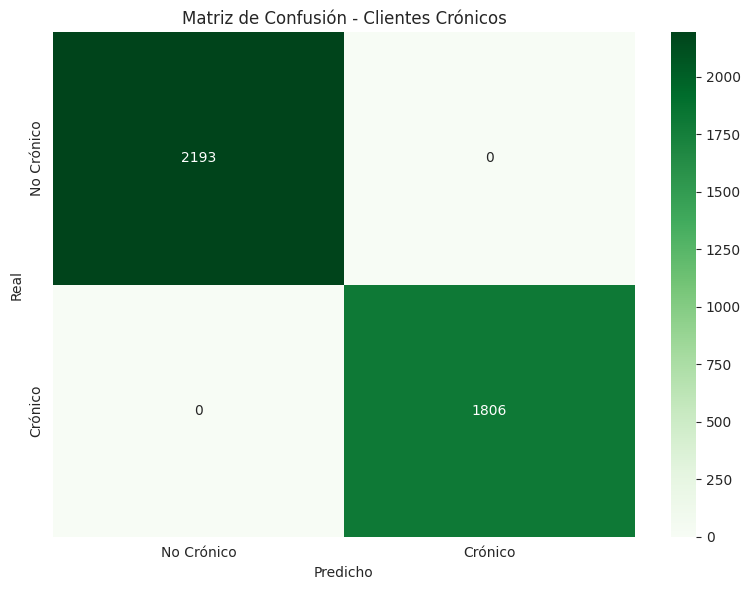

In [41]:
# Matriz de confusión
print("\nMatriz de confusión:")
cm_cron = confusion_matrix(y_test_cron, y_pred_cron)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cron, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Crónico', 'Crónico'],
            yticklabels=['No Crónico', 'Crónico'])
plt.title('Matriz de Confusión - Clientes Crónicos')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════
# 9. EXPORTAR MODELOS Y METADATA
# ═══════════════════════════════════════════════════════════════


In [42]:
print("\n\n💾 PASO 8: EXPORTAR MODELOS Y ARTIFACTS")
print("="*70)



💾 PASO 8: EXPORTAR MODELOS Y ARTIFACTS


In [43]:
# Guardar modelos
print("\n📦 Guardando modelos...")
joblib.dump(modelo_segmentacion, 'modelo_segmentacion.pkl')
joblib.dump(scaler_seg, 'scaler_segmentacion.pkl')

joblib.dump(modelo_prediccion, 'modelo_prediccion_estacional.pkl')
joblib.dump(le_cat, 'label_encoder_categorias.pkl')

joblib.dump(modelo_cronicos, 'modelo_clientes_cronicos.pkl')
joblib.dump(scaler_cron, 'scaler_cronicos.pkl')



📦 Guardando modelos...


['scaler_cronicos.pkl']

In [45]:
# Guardar metadata completa
metadata = {
    'fecha_entrenamiento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': {
        'transacciones_totales': len(df),
        'clientes_unicos': df['CLIENTE_ID'].nunique(),
        'periodo_inicio': df['FECHA'].min().strftime('%Y-%m-%d'),
        'periodo_fin': df['FECHA'].max().strftime('%Y-%m-%d'),
        'meses_datos': ((df['FECHA'].max() - df['FECHA'].min()).days / 30),
    },
    'umbrales_segmentacion': {
        'p50_mediana': float(p50),
        'p75_top25': float(p75),
        'p85_top15': float(p85),
        'p90_top10': float(p90),
        'definicion': {
            'FRECUENTE': f'>={p85:.0f} compras (top 15%)',
            'RECURRENTE': f'{p50:.0f}-{p85:.0f} compras',
            'ESPORÁDICO': f'<{p50:.0f} compras'
        }
    },
    'modelo_segmentacion': {
        'algoritmo': 'Random Forest Classifier',
        'accuracy_train': float(acc_train),
        'accuracy_test': float(acc_test),
        'f1_score_test': float(f1_test),
        'features': features_seg,
        'n_estimators': 150,
        'max_depth': 12
    },
    'modelo_prediccion': {
        'algoritmo': 'Random Forest Regressor',
        'mae_train': float(mae_train),
        'mae_test': float(mae),
        'rmse_test': float(rmse),
        'mape_test': float(mape),
        'meta_cumplida': bool(mape < 15),
        'features': features_pred,
        'n_estimators': 250,
        'max_depth': 20,
        'categorias_mapeadas': list(le_cat.classes_)
    },
    'modelo_cronicos': {
        'algoritmo': 'Logistic Regression',
        'accuracy_train': float(acc_train_cron),
        'accuracy_test': float(acc_test_cron),
        'f1_score_test': float(f1_test_cron),
        'features': features_cronico,
        'prevalencia_cronicos': float((y_cron == 1).sum() / len(y_cron))
    },
    'clasificacion_medicamentos': {
        'categorias_cronicas': CATEGORIAS_CRONICAS,
        'categorias_agudas': CATEGORIAS_AGUDAS
    }
}

import json
with open('metadata_modelos.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("\n✅ Archivos generados:")
print("  • modelo_segmentacion.pkl")
print("  • scaler_segmentacion.pkl")
print("  • modelo_prediccion_estacional.pkl")
print("  • label_encoder_categorias.pkl")
print("  • modelo_clientes_cronicos.pkl")
print("  • scaler_cronicos.pkl")
print("  • metadata_modelos.json")


✅ Archivos generados:
  • modelo_segmentacion.pkl
  • scaler_segmentacion.pkl
  • modelo_prediccion_estacional.pkl
  • label_encoder_categorias.pkl
  • modelo_clientes_cronicos.pkl
  • scaler_cronicos.pkl
  • metadata_modelos.json


In [51]:
# Descargar archivos
print("\n📥 Descargando archivos...")
try:
    files.download('modelo_segmentacion.pkl')
    files.download('scaler_segmentacion.pkl')
    files.download('modelo_prediccion_estacional.pkl')
    files.download('label_encoder_categorias.pkl')
    files.download('modelo_clientes_cronicos.pkl')
    files.download('scaler_cronicos.pkl')
    files.download('metadata_modelos.json')
    print("✅ Todos los archivos descargados")
except Exception as e:
    print(f"⚠️ Error al descargar: {e}")
    print("💡 Puedes descargar manualmente desde el panel izquierdo de archivos")


📥 Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Todos los archivos descargados


# ═══════════════════════════════════════════════════════════════
# 10. RESUMEN FINAL Y EJEMPLOS DE USO
# ═══════════════════════════════════════════════════════════════


In [47]:
print("\n\n✅ PIPELINE COMPLETADO EXITOSAMENTE")
print("="*70)

print("\n📊 RESUMEN DE RESULTADOS:")
print(f"\n1️⃣ SEGMENTACIÓN DE CLIENTES:")
print(f"   • Accuracy: {acc_test:.2%}")
print(f"   • F1-Score: {f1_test:.2%}")
print(f"   • Segmentos: ESPORÁDICO, RECURRENTE, FRECUENTE")

print(f"\n2️⃣ PREDICCIÓN ESTACIONAL:")
print(f"   • MAPE: {mape:.2f}% {'✅ META CUMPLIDA' if mape < 15 else '⚠️'}")
print(f"   • MAE: {mae:.2f} transacciones")
print(f"   • RMSE: {rmse:.2f} transacciones")

print(f"\n3️⃣ IDENTIFICACIÓN CLIENTES CRÓNICOS:")
print(f"   • Accuracy: {acc_test_cron:.2%}")
print(f"   • F1-Score: {f1_test_cron:.2%}")
print(f"   • Prevalencia: {(y_cron == 1).sum() / len(y_cron):.2%}")

print("\n\n📚 EJEMPLOS DE USO EN PRODUCCIÓN:")
print("="*70)



✅ PIPELINE COMPLETADO EXITOSAMENTE

📊 RESUMEN DE RESULTADOS:

1️⃣ SEGMENTACIÓN DE CLIENTES:
   • Accuracy: 100.00%
   • F1-Score: 100.00%
   • Segmentos: ESPORÁDICO, RECURRENTE, FRECUENTE

2️⃣ PREDICCIÓN ESTACIONAL:
   • MAPE: 27.69% ⚠️
   • MAE: 3.70 transacciones
   • RMSE: 9.59 transacciones

3️⃣ IDENTIFICACIÓN CLIENTES CRÓNICOS:
   • Accuracy: 100.00%
   • F1-Score: 100.00%
   • Prevalencia: 45.17%


📚 EJEMPLOS DE USO EN PRODUCCIÓN:


In [48]:
ejemplo_uso = """
# ═══════════════════════════════════════════════════════════════
# EJEMPLO 1: Segmentar un nuevo cliente
# ═══════════════════════════════════════════════════════════════

import joblib
import numpy as np

# Cargar modelos
modelo_seg = joblib.load('modelo_segmentacion.pkl')
scaler_seg = joblib.load('scaler_segmentacion.pkl')

# Datos de un cliente nuevo (en el mismo orden que features_seg)
cliente_nuevo = {
    'frecuencia': 12,
    'monto_total': 85000,
    'ticket_promedio': 7083,
    'recencia': 15,
    'productos_unicos': 8,
    'categorias_unicas': 4,
    'compras_cronicas': 3,
    'compras_agudas': 7,
    'lifetime_dias': 180,
    'tiene_cronicos': 1,
    'ratio_cronico_agudo': 0.43,
    'compras_no_farm': 2
}

# Preparar input
X_nuevo = np.array([[cliente_nuevo[f] for f in features_seg]])
X_nuevo_scaled = scaler_seg.transform(X_nuevo)

# Predecir
segmento = modelo_seg.predict(X_nuevo_scaled)[0]
probabilidades = modelo_seg.predict_proba(X_nuevo_scaled)[0]

print(f"Segmento predicho: {segmento}")
print(f"Probabilidades: {dict(zip(modelo_seg.classes_, probabilidades))}")

# ═══════════════════════════════════════════════════════════════
# EJEMPLO 2: Predecir demanda de un producto estacional
# ═══════════════════════════════════════════════════════════════

modelo_pred = joblib.load('modelo_prediccion_estacional.pkl')
le_cat = joblib.load('label_encoder_categorias.pkl')

# Predecir demanda de ANTIGRIPALES para Mayo 2026
datos_prediccion = {
    'mes': 5,  # Mayo
    'año': 2026,
    'categoria': 'ANTIGRIPAL',
    'trans_lag_1': 450,   # Transacciones del mes anterior (abril)
    'trans_lag_3': 380,   # Hace 3 meses (febrero)
    'trans_lag_6': 420,   # Hace 6 meses (noviembre 2025)
    'trans_lag_12': 520,  # Mismo mes año anterior (mayo 2025)
    'trans_ma_3': 415     # Promedio móvil 3 meses
}

# Preparar input
cat_encoded = le_cat.transform([datos_prediccion['categoria']])[0]
X_pred = np.array([[
    datos_prediccion['mes'],
    datos_prediccion['año'],
    cat_encoded,
    datos_prediccion['trans_lag_1'],
    datos_prediccion['trans_lag_3'],
    datos_prediccion['trans_lag_6'],
    datos_prediccion['trans_lag_12'],
    datos_prediccion['trans_ma_3']
]])

demanda_pred = modelo_pred.predict(X_pred)[0]
print(f"Demanda predicha para ANTIGRIPALES en Mayo 2026:")
print(f"  {int(demanda_pred)} transacciones esperadas")

# ═══════════════════════════════════════════════════════════════
# EJEMPLO 3: Identificar si un cliente es crónico
# ═══════════════════════════════════════════════════════════════

modelo_cron = joblib.load('modelo_clientes_cronicos.pkl')
scaler_cron = joblib.load('scaler_cronicos.pkl')

# Datos de cliente a evaluar
cliente_eval = {
    'frecuencia': 10,
    'monto_total': 120000,
    'ticket_promedio': 12000,
    'categorias_unicas': 5,
    'recencia': 30,
    'lifetime_dias': 300,
    'compras_agudas': 4,
    'productos_unicos': 9,
    'ratio_cronico_agudo': 1.5,
    'compras_no_farm': 1
}

# Preparar input
X_eval = np.array([[cliente_eval[f] for f in features_cronico]])
X_eval_scaled = scaler_cron.transform(X_eval)

# Predecir
es_cronico = modelo_cron.predict(X_eval_scaled)[0]
prob_cronico = modelo_cron.predict_proba(X_eval_scaled)[0][1]

print(f"Cliente crónico: {'Sí' if es_cronico else 'No'}")
print(f"Probabilidad: {prob_cronico:.2%}")
"""

In [49]:
print(ejemplo_uso)

print("\n🎉 ¡PIPELINE DE ML COMPLETADO CON ÉXITO!")
print("\nPróximos pasos:")
print("1. Integrar modelos en el backend Django")
print("2. Crear API endpoints para predicciones")
print("3. Desarrollar dashboard de visualización")
print("4. Validar con más datos de la farmacia piloto")
print("\n" + "="*70)


# ═══════════════════════════════════════════════════════════════
# EJEMPLO 1: Segmentar un nuevo cliente
# ═══════════════════════════════════════════════════════════════

import joblib
import numpy as np

# Cargar modelos
modelo_seg = joblib.load('modelo_segmentacion.pkl')
scaler_seg = joblib.load('scaler_segmentacion.pkl')

# Datos de un cliente nuevo (en el mismo orden que features_seg)
cliente_nuevo = {
    'frecuencia': 12,
    'monto_total': 85000,
    'ticket_promedio': 7083,
    'recencia': 15,
    'productos_unicos': 8,
    'categorias_unicas': 4,
    'compras_cronicas': 3,
    'compras_agudas': 7,
    'lifetime_dias': 180,
    'tiene_cronicos': 1,
    'ratio_cronico_agudo': 0.43,
    'compras_no_farm': 2
}

# Preparar input
X_nuevo = np.array([[cliente_nuevo[f] for f in features_seg]])
X_nuevo_scaled = scaler_seg.transform(X_nuevo)

# Predecir
segmento = modelo_seg.predict(X_nuevo_scaled)[0]
probabilidades = modelo_seg.predict_proba(X_nuevo_scaled)[0]

print(f"Segmento pred